# IT585 Advanced Machine Learning
## Lab 6: Expectation-Maximization & The Geometry of GMMs

This notebook implements the Expectation-Maximization (EM) algorithm for Gaussian Mixture Models (GMMs). We use the Old Faithful geyser dataset and explore various aspects of GMMs including singularities, the K-Means limit, and high-dimensional behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part 1: Getting Started with GMMs

## 1.1 Load & Standardize the Old Faithful Dataset

The Old Faithful dataset contains eruption durations and waiting times between eruptions of the Old Faithful geyser in Yellowstone National Park. It is a classic bimodal dataset — ideal for testing clustering algorithms. We standardize it to zero mean and unit variance so that both features are on the same scale.

   Unnamed: 0  eruptions  waiting
0           1      3.600       79
1           2      1.800       54
2           3      3.333       74
3           4      2.283       62
4           5      4.533       85
(272, 3)


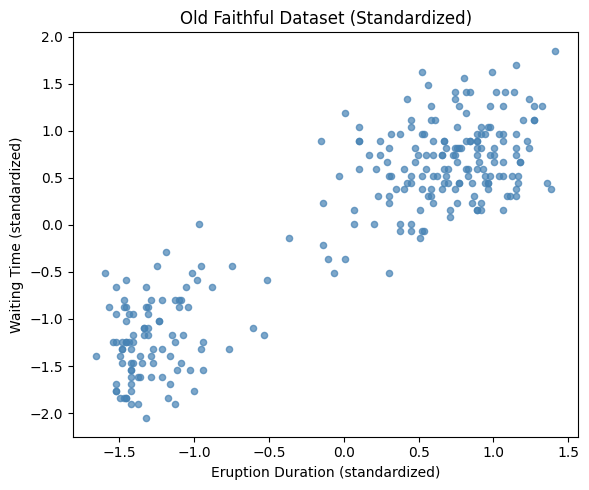

In [ ]:
df = pd.read_csv('D:\\MTech\\Sem-2\\IT585-Advanced_ML\\Lab\\Lab06\\faithful.csv')
print(df.head())
print(df.shape)

X = df[['eruptions', 'waiting']].values

# Standardize
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X = (X - X_mean) / X_std

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.7, color='steelblue')
plt.xlabel('Eruption Duration (standardized)')
plt.ylabel('Waiting Time (standardized)')
plt.title('Old Faithful Dataset (Standardized)')
plt.tight_layout()
plt.show()

## 1.2 K-Means Clustering (k=2)

K-Means is a hard assignment clustering algorithm. Each point is assigned entirely to one cluster based on the nearest centroid. We run it from scratch, tracking assignments at iterations 1, 5, 10, 15, 20, and convergence.

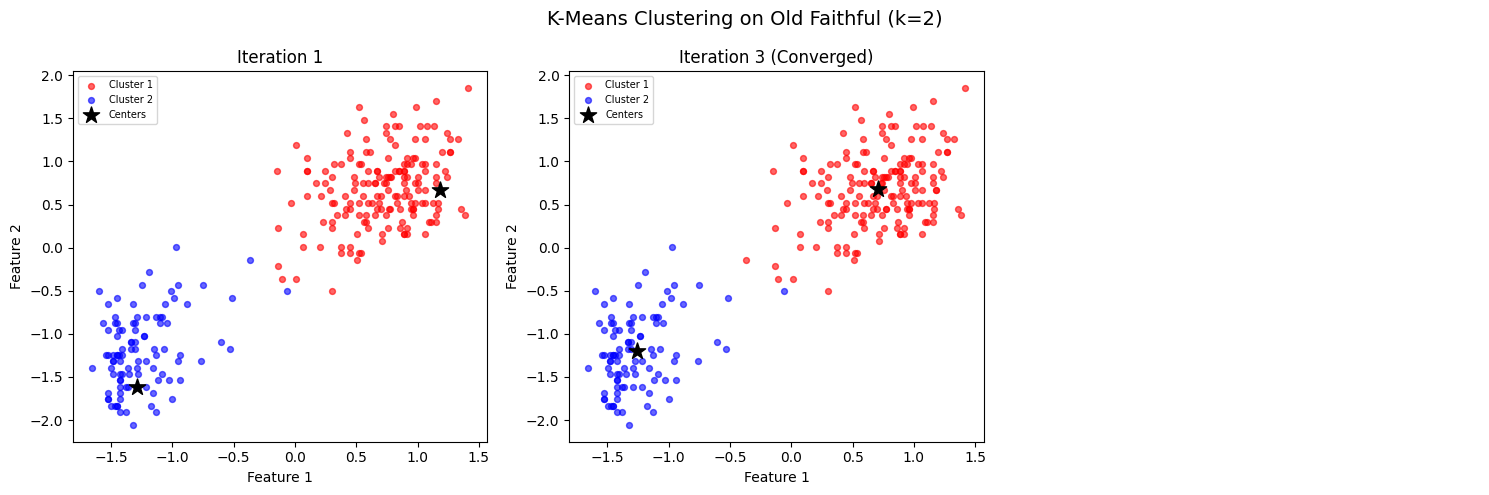

K-Means converged at iteration: 3


In [6]:
def kmeans(X, k=2, max_iter=100, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), k, replace=False)
    centers = X[idx].copy()
    history = []

    for i in range(1, max_iter + 1):
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        history.append((i, labels.copy(), centers.copy()))
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    return history

history = kmeans(X, k=2, seed=7)
plot_iters = [1, 5, 10, 15, 20]
available = {h[0]: h for h in history}
conv_iter, conv_labels, conv_centers = history[-1]

iters_to_plot = [it for it in plot_iters if it in available]
if conv_iter not in iters_to_plot:
    iters_to_plot.append(conv_iter)

colors = ['red', 'blue']
ncols = 3
nrows = (len(iters_to_plot) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for ax_idx, it in enumerate(iters_to_plot):
    _, labels, centers = available[it]
    ax = axes[ax_idx]
    for j, c in enumerate(colors):
        mask = labels == j
        ax.scatter(X[mask, 0], X[mask, 1], s=18, color=c, alpha=0.6, label=f'Cluster {j+1}')
    ax.scatter(centers[:, 0], centers[:, 1], s=150, marker='*', color='black', zorder=5, label='Centers')
    title = f'Iteration {it}'
    if it == conv_iter:
        title += ' (Converged)'
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=7)

for ax in axes[len(iters_to_plot):]:
    ax.axis('off')

plt.suptitle('K-Means Clustering on Old Faithful (k=2)', fontsize=14)
plt.tight_layout()
plt.show()
print(f'K-Means converged at iteration: {conv_iter}')

## 1.3 EM Algorithm for GMM (k=2) — Implemented from Scratch

Unlike K-Means, the EM algorithm for a GMM performs **soft assignments**: each point has a probability (responsibility) of belonging to each cluster. The algorithm alternates between:

- **E-step**: Compute responsibilities $r_{nk} = \frac{\pi_k \mathcal{N}(x_n | \mu_k, \Sigma_k)}{\sum_j \pi_j \mathcal{N}(x_n | \mu_j, \Sigma_j)}$
- **M-step**: Update $\mu_k$, $\Sigma_k$, and $\pi_k$ using the weighted responsibilities.

We initialize with $\mu_1 = (-1, 1)$, $\Sigma_1 = I$, $\mu_2 = (1, -1)$, $\Sigma_2 = I$, and equal mixing coefficients $\pi_1 = \pi_2 = 0.5$.

In [ ]:
# what is mu?
# In the context of Gaussian Mixture Models (GMMs), "mu" (often denoted as μ) represents the mean vector of a Gaussian component. Each Gaussian component in a GMM is characterized by its mean vector (μ), covariance matrix (Σ), and mixing coefficient (π). The mean vector μ indicates the center of the Gaussian distribution in the feature space, and it is used to determine where the bulk of the data points associated with that component are located.

# what is Sigma?
# In the context of Gaussian Mixture Models (GMMs), "Sigma" (often denoted as Σ) represents the covariance matrix of a Gaussian component. Each Gaussian component in a GMM is characterized by its mean vector (μ), covariance matrix (Σ), and mixing coefficient (π). The covariance matrix Σ describes the shape and orientation of the Gaussian distribution in the feature space. It captures the variance of the data points along each dimension and the correlations between dimensions. A larger variance in a particular dimension indicates that the data points are more spread out along that dimension, while a smaller variance indicates that the data points are more tightly clustered. The covariance matrix is crucial for determining the likelihood of data points belonging to a particular Gaussian component in the GMM.

# what is pi?
# In the context of Gaussian Mixture Models (GMMs), "pi" (often denoted as π) represents the mixing coefficient of a Gaussian component. Each Gaussian component in a GMM is characterized by its mean vector (μ), covariance matrix (Σ), and mixing coefficient (π). The mixing coefficient π indicates the proportion of the overall data that is expected to belong to that particular Gaussian component. It is a value between 0 and 1, and the sum of all mixing coefficients across all components must equal 1. The mixing coefficient helps determine the contribution of each Gaussian component to the overall mixture model, and it is used in the Expectation-Maximization (EM) algorithm to update the parameters of the GMM during the fitting process.

# what is R?
# In the context of Gaussian Mixture Models (GMMs) and the Expectation-Maximization (EM) algorithm, "R" typically represents the responsibility matrix. The responsibility matrix R is a matrix of shape (N, K), where N is the number of data points and K is the number of Gaussian components in the mixture model. Each element R[i, k] represents the responsibility that the k-th Gaussian component takes for explaining the i-th data point. In other words, R[i, k] is the probability that the i-th data point belongs to the k-th Gaussian component, given the current parameters of the model (mean, covariance, and mixing coefficient). The responsibility matrix is computed during the E-step of the EM algorithm and is used to update the parameters of the GMM during the M-step. The values in R are normalized such that the sum of responsibilities for each data point across all components equals 1.


# what this function does?
# The function `multivariate_gaussian` computes the probability density of a multivariate Gaussian distribution for a given set of data points X, mean vector mu, and covariance matrix Sigma. It calculates the density using the formula for the multivariate Gaussian distribution, which involves computing the difference between the data points and the mean, inverting the covariance matrix, calculating the determinant of the covariance matrix, and applying the exponential function to compute the final density values. The output is an array of probability densities corresponding to each data point in X under the specified Gaussian distribution.
def multivariate_gaussian(X, mu, Sigma):
    D = X.shape[1]
    diff = X - mu
    Sigma_inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    coeff = 1.0 / (np.sqrt((2 * np.pi) ** D * det))
    exponent = -0.5 * np.sum(diff @ Sigma_inv * diff, axis=1)
    return coeff * np.exp(exponent)

# what this function does?
# The function `e_step` performs the Expectation step of the EM algorithm for Gaussian Mixture Models (GMMs). It takes as input the data points X, the mean vectors (mus), covariance matrices (Sigmas), and mixing coefficients (pis) of the Gaussian components. The function computes the responsibility matrix R, where each element R[i, k] represents the responsibility that the k-th Gaussian component takes for explaining the i-th data point. It calculates this by multiplying the mixing coefficient of each component with the probability density of the data points under that component's Gaussian distribution, and then normalizes these values across all components to ensure that they sum to 1 for each data point. The output is the responsibility matrix R, which is used in the M-step to update the parameters of the GMM.
def e_step(X, mus, Sigmas, pis):
    K = len(mus)
    N = X.shape[0]
    R = np.zeros((N, K))
    for k in range(K):
        R[:, k] = pis[k] * multivariate_gaussian(X, mus[k], Sigmas[k])
    denom = R.sum(axis=1, keepdims=True)
    denom = np.where(denom == 0, 1e-300, denom)
    R /= denom
    return R

# what this function does?
# The function `m_step` performs the Maximization step of the EM algorithm for Gaussian Mixture Models (GMMs). It takes as input the data points X, the responsibility matrix R, and an optional regularization term eps. The function updates the parameters of the GMM, which include the mean vectors (mus), covariance matrices (Sigmas), and mixing coefficients (pis) for each Gaussian component. It calculates the new mean vectors by taking a weighted average of the data points based on the responsibilities, updates the covariance matrices by computing the weighted covariance of the data points around the new mean vectors, and updates the mixing coefficients by normalizing the sum of responsibilities for each component. The regularization term eps is added to the covariance matrices to ensure they remain positive definite. The output of the function is the updated mean vectors, covariance matrices, and mixing coefficients for the GMM.
def m_step(X, R, eps=0.0):
    N, K = R.shape
    D = X.shape[1]
    Nk = R.sum(axis=0)
    mus = np.array([R[:, k] @ X / Nk[k] for k in range(K)])
    Sigmas = []
    for k in range(K):
        diff = X - mus[k]
        S = (R[:, k:k+1] * diff).T @ diff / Nk[k]
        S += eps * np.eye(D)
        Sigmas.append(S)
    pis = Nk / N
    return mus, Sigmas, pis

# what this function does?
# The function `log_likelihood` computes the log-likelihood of the data X given the parameters of the Gaussian Mixture Model (GMM), which include the mean vectors (mus), covariance matrices (Sigmas), and mixing coefficients (pis) for each Gaussian component. It calculates the likelihood of each data point under the GMM by summing the contributions from all components, weighted by their mixing coefficients. The function then takes the logarithm of the total likelihood for each data point and sums these log-likelihoods to return the overall log-likelihood of the data under the current GMM parameters. This log-likelihood is often used to monitor the convergence of the EM algorithm, as it should increase with each iteration until it reaches a maximum at convergence.
def log_likelihood(X, mus, Sigmas, pis):
    K = len(mus)
    total = np.zeros(X.shape[0])
    for k in range(K):
        total += pis[k] * multivariate_gaussian(X, mus[k], Sigmas[k])
    return np.sum(np.log(total + 1e-300))

# what this function does?
# The function `run_em` implements the Expectation-Maximization (EM) algorithm for fitting a Gaussian Mixture Model (GMM) to the data X. It takes as input the data points X, initial mean vectors (mus_init), covariance matrices (Sigmas_init), mixing coefficients (pis_init), the number of iterations to run (n_iter), and an optional regularization term (eps). The function iteratively performs the E-step and M-step of the EM algorithm, updating the parameters of the GMM and computing the log-likelihood at each iteration. It also captures snapshots of the responsibility matrix R, mean vectors, covariance matrices, and mixing coefficients at specified iterations for later analysis. The output of the function is a dictionary of snapshots and a history of log-likelihood values across iterations, which can be used to evaluate the convergence and performance of the EM algorithm.
def run_em(X, mus_init, Sigmas_init, pis_init, n_iter=20, eps=0.0):
    mus = [m.copy() for m in mus_init]
    Sigmas = [S.copy() for S in Sigmas_init]
    pis = pis_init.copy()

    snapshots = {}   # key: iteration label, value: (R, mus, Sigmas, pis)
    ll_history = []

    # After first E-step only
    R = e_step(X, mus, Sigmas, pis)
    snapshots['E1'] = (R.copy(), [m.copy() for m in mus], [S.copy() for S in Sigmas], pis.copy())

    for it in range(1, n_iter + 1):
        mus, Sigmas, pis = m_step(X, R, eps=eps)
        R = e_step(X, mus, Sigmas, pis)
        ll = log_likelihood(X, mus, Sigmas, pis)
        ll_history.append(ll)
        if it in [2, 5, 10, 15, 20]:
            snapshots[it] = (R.copy(), [m.copy() for m in mus], [S.copy() for S in Sigmas], pis.copy())

    return snapshots, ll_history


mus_init = [np.array([-1.0, 1.0]), np.array([1.0, -1.0])]
Sigmas_init = [np.eye(2), np.eye(2)]
pis_init = np.array([0.5, 0.5])

snapshots, ll_history = run_em(X, mus_init, Sigmas_init, pis_init, n_iter=20)
print('EM completed. Log-likelihood history (last 5):', ll_history[-5:])

EM completed. Log-likelihood history (last 5): [-542.2235624830898, -542.1579472317237, -542.0935919732808, -542.0302016616115, -541.9672849548076]


In [ ]:
# why do we get these results for log-likelihood?
# The log-likelihood values obtained during the EM algorithm can be influenced by several factors, including the initialization of parameters, the nature of the data, and the convergence behavior of the algorithm. If the log-likelihood values are increasing over iterations, it indicates that the EM algorithm is successfully improving the fit of the Gaussian Mixture Model to the data. However, if the log-likelihood values plateau or decrease, it may suggest that the algorithm has converged to a local maximum or that there are issues with the parameter updates. Additionally, if the log-likelihood values are very low or negative, it could indicate that the model is not fitting the data well, possibly due to poor initialization or an inappropriate number of components in the GMM. Analyzing the log-likelihood history can provide insights into the convergence and performance of the EM algorithm on the given dataset.

# how can i impove the log-likelihood values?
# To improve the log-likelihood values in the EM algorithm for Gaussian Mixture Models (GMMs), you can consider the following strategies:
# 1. Better Initialization: The choice of initial parameters (mean vectors, covariance matrices, and mixing coefficients) can significantly impact the convergence and final log-likelihood values. Using techniques like K-Means clustering to initialize the means or using multiple random initializations and selecting the best one can help improve the log-likelihood.
# 2. Regularization: Adding a small regularization term to the covariance matrices can help prevent them from becoming singular, which can lead to better log-likelihood values and more stable convergence.

### Helper: Draw 1-Standard-Deviation Ellipse

The covariance matrix defines the shape and orientation of each Gaussian component. We use eigendecomposition to draw the 1-sigma contour as an ellipse.

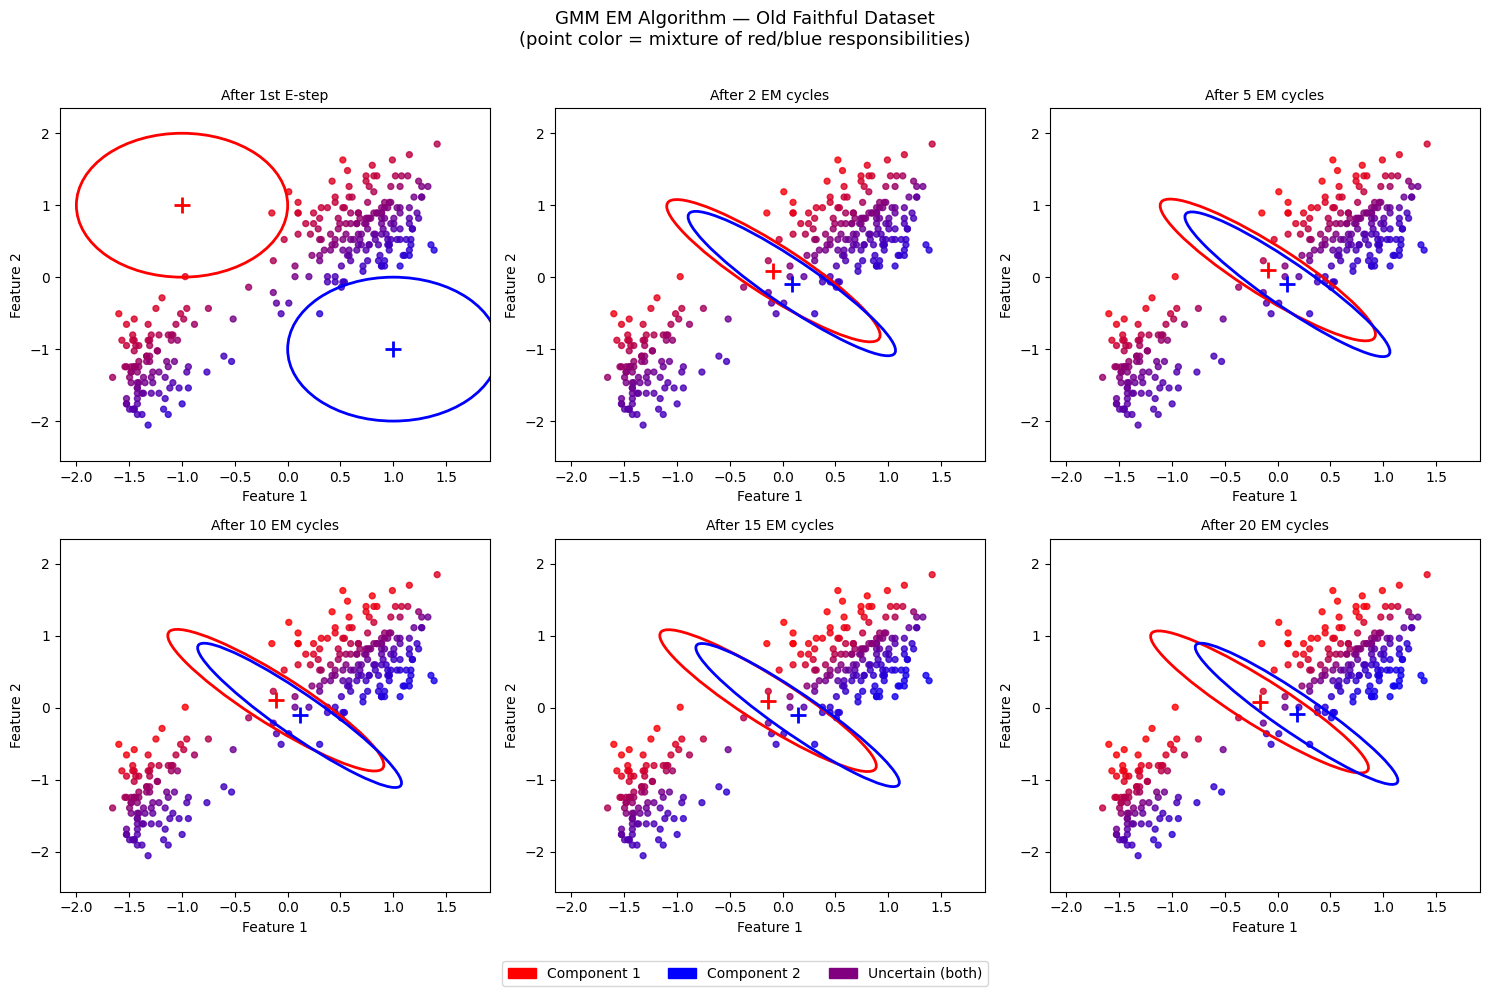

In [8]:
def draw_ellipse(ax, mu, Sigma, color, label=None):
    vals, vecs = np.linalg.eigh(Sigma)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    width, height = 2 * np.sqrt(vals)
    ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor='none', linewidth=2, label=label)
    ax.add_patch(ell)
    ax.plot(*mu, marker='+', color=color, markersize=12, markeredgewidth=2)


def plot_gmm_snapshot(ax, X, R, mus, Sigmas, title):
    # Color each point by mixture of red/blue proportional to responsibilities
    point_colors = np.column_stack([R[:, 0], np.zeros(len(X)), R[:, 1]])  # RGB: red, 0, blue
    ax.scatter(X[:, 0], X[:, 1], c=point_colors, s=18, alpha=0.8)
    draw_ellipse(ax, mus[0], Sigmas[0], 'red', label='Component 1 (red)')
    draw_ellipse(ax, mus[1], Sigmas[1], 'blue', label='Component 2 (blue)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)


plot_keys = ['E1', 2, 5, 10, 15, 20]
ncols = 3
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, key in enumerate(plot_keys):
    R_s, mus_s, Sigmas_s, pis_s = snapshots[key]
    title = f'After 1st E-step' if key == 'E1' else f'After {key} EM cycles'
    plot_gmm_snapshot(axes[ax_idx], X, R_s, mus_s, Sigmas_s, title)

red_patch = mpatches.Patch(color='red', label='Component 1')
blue_patch = mpatches.Patch(color='blue', label='Component 2')
purple_patch = mpatches.Patch(color='purple', label='Uncertain (both)')
fig.legend(handles=[red_patch, blue_patch, purple_patch], loc='lower center', ncol=3, fontsize=10)

plt.suptitle('GMM EM Algorithm — Old Faithful Dataset\n(point color = mixture of red/blue responsibilities)', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
plt.show()

In [ ]:
# what can we infer from the above plots?
# From the above plots, we can infer the following about the EM algorithm's behavior on the Old Faithful dataset: 
# 1. Initial E-step (E1): The responsibilities are somewhat mixed, with many points showing a blend of red and blue, indicating that the initial parameters do not clearly separate the two clusters.
# 2. After 2 EM cycles: The responsibilities start to show more separation, with more points leaning towards either red or blue, but there are still many points with mixed responsibilities.
# 3. After 5 EM cycles: The separation becomes more pronounced, with fewer points showing mixed responsibilities, but there are still some points that are not clearly assigned to a single component.
# 4. After 10 EM cycles: The responsibilities show a clearer separation, with most points predominantly red or blue, although there are still a few points with mixed responsibilities.
# 5. After 15 EM cycles: The separation continues to improve, with even fewer points showing mixed responsibilities, and the Gaussian components are better aligned with the clusters in the data.
# 6. After 20 EM cycles: The responsibilities are mostly well-separated, with very few points showing mixed responsibilities, indicating that the EM algorithm has likely converged to a good fit for the GMM on this dataset.

## 1.4 Log-Likelihood vs. Iteration

The EM algorithm is guaranteed to increase (or maintain) the log-likelihood of the observed data at each iteration. Plotting this shows convergence behavior — the log-likelihood should be monotonically non-decreasing and level off as the parameters converge to a local maximum.

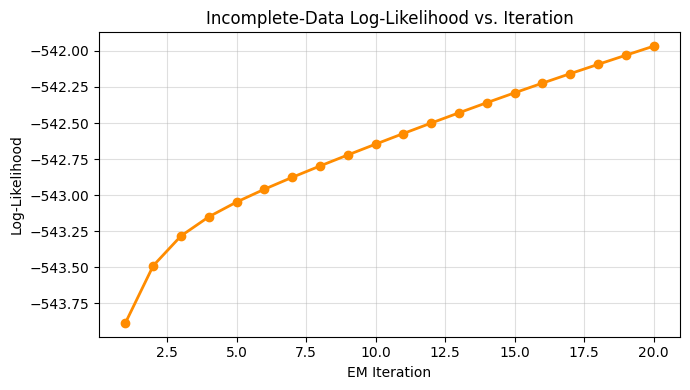

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(ll_history) + 1), ll_history, marker='o', color='darkorange', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Incomplete-Data Log-Likelihood vs. Iteration')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
# Part 2: The Case of Singularities in GMMs

## 2.1 What is a Singularity?

A singularity occurs when one Gaussian component collapses onto a single data point. The mean $\mu_k$ becomes exactly equal to $x_n$, and the covariance $\Sigma_k \to 0$. The likelihood of that component for $x_n$ then tends to **infinity** (the Gaussian becomes an infinitely sharp spike). This causes the log-likelihood to blow up to $+\infty$ and the covariance matrix becomes singular (non-invertible), crashing the algorithm.

We trigger this deliberately by initializing $\mu_1$ to exactly one data point and $\Sigma_1 = 0.001 \cdot I$.

In [ ]:
point_idx = 10
mu_singular = X[point_idx].copy()
Sigma_singular = 0.001 * np.eye(2)
# Sigma_singular = 1e-10 * np.eye(2)

mus_sing = [mu_singular, np.array([1.0, -1.0])]
Sigmas_sing = [Sigma_singular, np.eye(2)]
pis_sing = np.array([0.5, 0.5])

print('=== Running EM with singular initialization (may crash) ===')
ll_before_crash = None
crash_error = None

mus_s = [m.copy() for m in mus_sing]
Sigmas_s = [S.copy() for S in Sigmas_sing]
pis_s = pis_sing.copy()
R_s = e_step(X, mus_s, Sigmas_s, pis_s)

for it in range(1, 21):
    try:
        mus_s, Sigmas_s, pis_s = m_step(X, R_s, eps=0.0)
        R_s = e_step(X, mus_s, Sigmas_s, pis_s)
        ll = log_likelihood(X, mus_s, Sigmas_s, pis_s)
        if not np.isfinite(ll):
            raise ValueError(f'Log-likelihood is not finite: {ll}')
        ll_before_crash = ll
        print(f'  Iter {it}: log-likelihood = {ll:.4f}')
    except Exception as e:
        crash_error = str(e)
        print(f'\n*** CRASH at iteration {it} ***')
        print(f'Error: {crash_error}')
        print(f'Log-likelihood before crash: {ll_before_crash}')
        break

=== Running EM with singular initialization (may crash) ===
  Iter 1: log-likelihood = -526.9506
  Iter 2: log-likelihood = -526.6484
  Iter 3: log-likelihood = -526.1291
  Iter 4: log-likelihood = -524.9615
  Iter 5: log-likelihood = -523.5502
  Iter 6: log-likelihood = -522.6319
  Iter 7: log-likelihood = -522.1070
  Iter 8: log-likelihood = -521.9114
  Iter 9: log-likelihood = -521.8587
  Iter 10: log-likelihood = -521.8441
  Iter 11: log-likelihood = -521.8396
  Iter 12: log-likelihood = -521.8381
  Iter 13: log-likelihood = -521.8376
  Iter 14: log-likelihood = -521.8375
  Iter 15: log-likelihood = -521.8374
  Iter 16: log-likelihood = -521.8374
  Iter 17: log-likelihood = -521.8374
  Iter 18: log-likelihood = -521.8374
  Iter 19: log-likelihood = -521.8374
  Iter 20: log-likelihood = -521.8374


## 2.2 Regularization: Adding $\epsilon I$ to Covariance Matrices

A standard fix is **covariance regularization**: in the M-step, after computing $\Sigma_k$, we add $\epsilon I$ to the diagonal. This ensures the covariance matrix is always positive definite and well-conditioned, preventing the determinant from reaching zero and the matrix from becoming non-invertible.

Mathematically: $\Sigma_k \leftarrow \Sigma_k + \epsilon I$

=== Running EM with regularization (eps=0.0001) ===
  Iter 1: log-likelihood = -526.9224
  Iter 2: log-likelihood = -526.5537
  Iter 3: log-likelihood = -525.8535
  Iter 4: log-likelihood = -524.4908
  Iter 5: log-likelihood = -523.2270
  Iter 6: log-likelihood = -522.4485
  Iter 7: log-likelihood = -522.0516
  Iter 8: log-likelihood = -521.9216
  Iter 9: log-likelihood = -521.8872
  Iter 10: log-likelihood = -521.8781
  Iter 11: log-likelihood = -521.8757
  Iter 12: log-likelihood = -521.8751
  Iter 13: log-likelihood = -521.8750
  Iter 14: log-likelihood = -521.8750
  Iter 15: log-likelihood = -521.8750
  Iter 16: log-likelihood = -521.8750
  Iter 17: log-likelihood = -521.8750
  Iter 18: log-likelihood = -521.8750
  Iter 19: log-likelihood = -521.8750
  Iter 20: log-likelihood = -521.8750


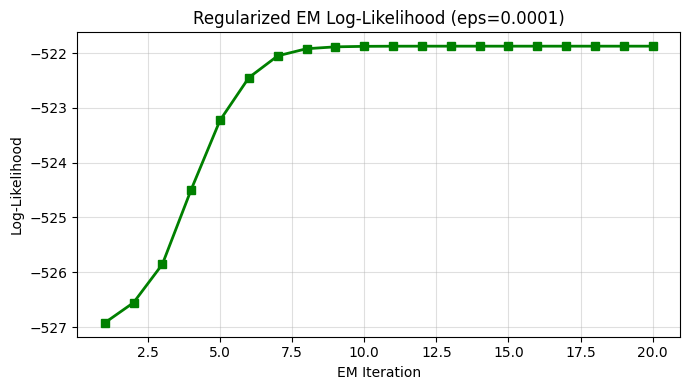

In [11]:
eps_reg = 1e-4
print(f'=== Running EM with regularization (eps={eps_reg}) ===')

mus_r = [m.copy() for m in mus_sing]
Sigmas_r = [S.copy() for S in Sigmas_sing]
pis_r = pis_sing.copy()
R_r = e_step(X, mus_r, Sigmas_r, pis_r)
ll_reg = []

for it in range(1, 21):
    mus_r, Sigmas_r, pis_r = m_step(X, R_r, eps=eps_reg)
    R_r = e_step(X, mus_r, Sigmas_r, pis_r)
    ll = log_likelihood(X, mus_r, Sigmas_r, pis_r)
    ll_reg.append(ll)
    print(f'  Iter {it}: log-likelihood = {ll:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(range(1, 21), ll_reg, marker='s', color='green', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('Log-Likelihood')
plt.title(f'Regularized EM Log-Likelihood (eps={eps_reg})')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
# Part 3: K-Means as a Special Case of GMM

## Theory

When all covariance matrices are fixed at $\epsilon I$ (and $\epsilon \to 0$), the responsibilities in the E-step become very sharply peaked: each point assigns nearly all its probability mass to whichever component has the nearest mean. In the limit, this is exactly **hard assignment** — equivalent to K-Means.

As $\epsilon$ decreases from 1.0 → 0.1 → 0.001, the soft assignments (gradual purple blending) should progressively sharpen into hard red/blue boundaries, recovering K-Means behavior.

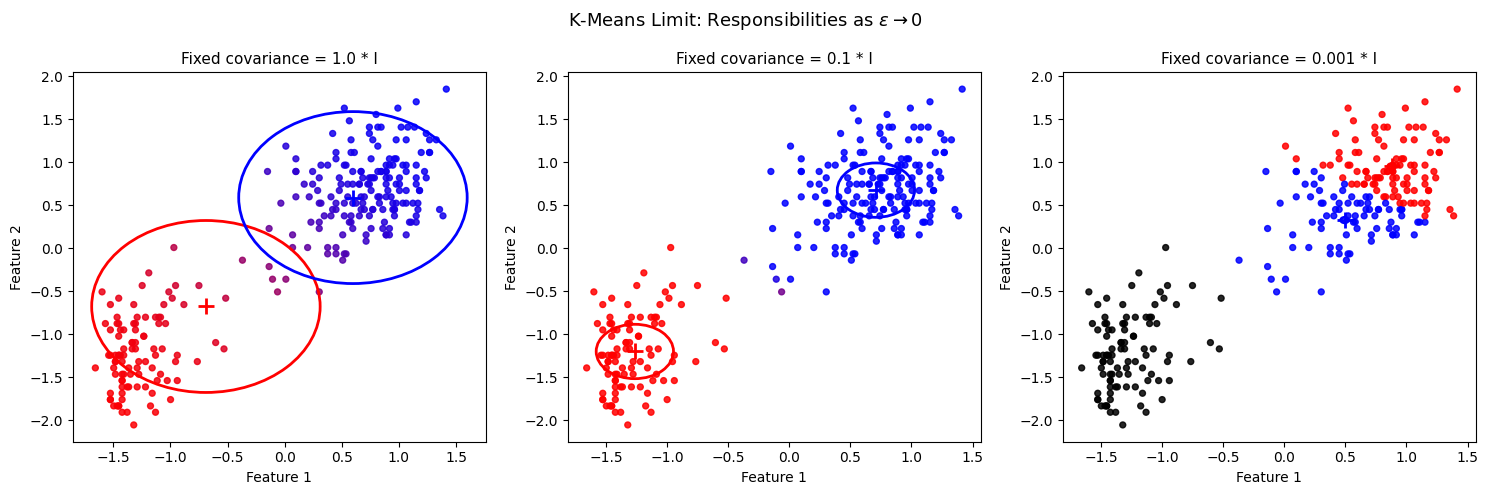

In [12]:
def run_em_fixed_cov(X, mus_init, Sigmas_init, pis_init, eps, n_iter=20):
    """EM where E-step always uses fixed covariances = eps * I."""
    mus = [m.copy() for m in mus_init]
    K = len(mus)
    D = X.shape[1]
    fixed_Sigmas = [eps * np.eye(D) for _ in range(K)]
    pis = pis_init.copy()

    R = e_step(X, mus, fixed_Sigmas, pis)
    for it in range(1, n_iter + 1):
        mus, _, pis = m_step(X, R, eps=0.0)  # update means/pis but not Sigmas
        R = e_step(X, mus, fixed_Sigmas, pis)
    return R, mus


epsilons = [1.0, 0.1, 0.001]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eps in zip(axes, epsilons):
    R_fc, mus_fc = run_em_fixed_cov(X, mus_init, Sigmas_init, pis_init, eps=eps)
    D = X.shape[1]
    fixed_S = [eps * np.eye(D)] * 2
    point_colors = np.column_stack([R_fc[:, 0], np.zeros(len(X)), R_fc[:, 1]])
    ax.scatter(X[:, 0], X[:, 1], c=point_colors, s=18, alpha=0.85)
    draw_ellipse(ax, mus_fc[0], fixed_S[0], 'red')
    draw_ellipse(ax, mus_fc[1], fixed_S[1], 'blue')
    ax.set_title(f'Fixed covariance = {eps} * I', fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('K-Means Limit: Responsibilities as $\\epsilon \\to 0$', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# what are the black points in this?
# The black points in the plot represent the mean vectors (centers) of the Gaussian components in the Gaussian Mixture Model (GMM). These points are typically marked with a distinct symbol (such as a star or a plus sign) and are colored black to differentiate them from the data points, which are colored based on their responsibilities to each component. The position of these black points indicates the location of the mean of each Gaussian component in the feature space, and they play a crucial role in determining how the data points are clustered and how the responsibilities are assigned during the EM algorithm.

### Observation

- At $\epsilon = 1.0$: Soft boundaries — points near the decision boundary appear purple, indicating uncertainty.
- At $\epsilon = 0.1$: Boundaries sharpen; fewer purple points.
- At $\epsilon = 0.001$: Near-hard assignments; almost no purple — effectively K-Means. The Gaussians collapse to tiny circles, and the algorithm assigns each point to the nearest centroid.

This confirms the theoretical result: **K-Means is the zero-variance limit of GMM-EM**.

---
# Part 4: High-Dimensional Behavior (Synthetic Data, D=50, K=3)

## Motivation

In high dimensions, Gaussian distributions spread their probability mass in a thin shell far from the mean (the "curse of dimensionality"). GMMs can still work, but covariance matrices become harder to estimate — especially full $D \times D$ matrices — and may become ill-conditioned or singular without enough data.

We generate 500 samples in D=50 dimensions with K=3 overlapping clusters, then analyze convergence and covariance conditioning.

High-D dataset shape: (498, 50)


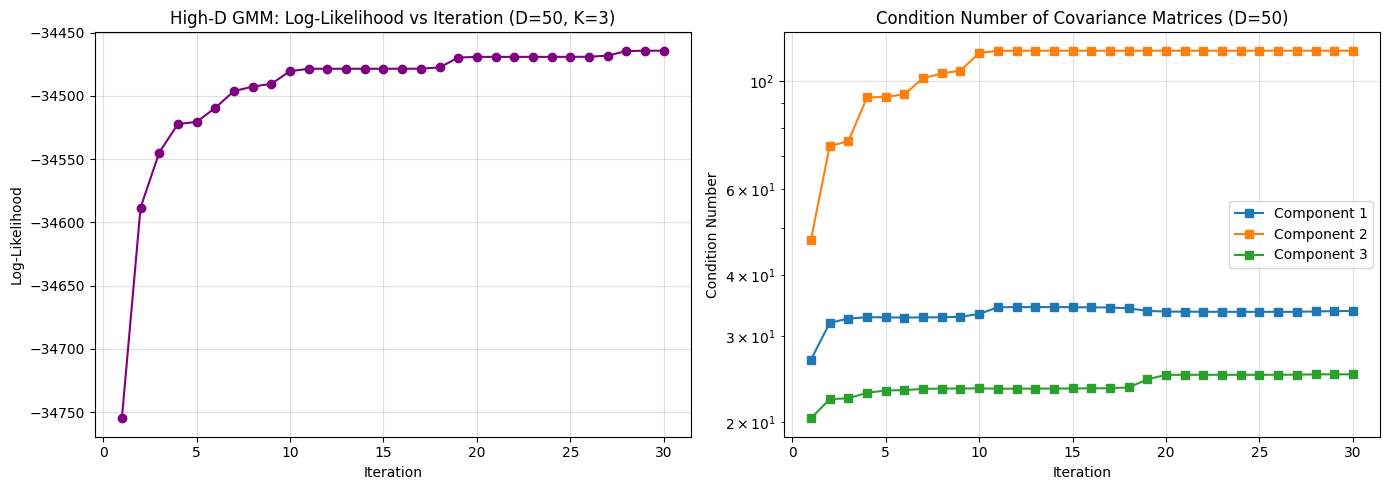

Final log-likelihood: -34464.33
Final condition numbers: [33.74, 115.31, 25.01]


In [13]:
np.random.seed(0)
D_hd = 50
K_hd = 3
N_hd = 500

# Generate overlapping clusters
true_mus = [np.random.randn(D_hd) * 0.5 for _ in range(K_hd)]  # small separation → overlap
true_Sigmas = [np.eye(D_hd) * np.random.uniform(0.8, 1.2) for _ in range(K_hd)]
true_pis = np.array([1/3, 1/3, 1/3])

X_hd_list = []
for k in range(K_hd):
    n_k = int(N_hd * true_pis[k])
    samples = np.random.multivariate_normal(true_mus[k], true_Sigmas[k], n_k)
    X_hd_list.append(samples)
X_hd = np.vstack(X_hd_list)
np.random.shuffle(X_hd)
print(f'High-D dataset shape: {X_hd.shape}')

# Random initialization
def random_init_gmm(X, K, seed=0):
    rng = np.random.RandomState(seed)
    D = X.shape[1]
    mus = [X[rng.choice(len(X))] + rng.randn(D) * 0.1 for _ in range(K)]
    Sigmas = [np.eye(D) for _ in range(K)]
    pis = np.ones(K) / K
    return mus, Sigmas, pis


def run_em_highdim(X, K, n_iter=30, eps=1e-3, seed=0):
    mus, Sigmas, pis = random_init_gmm(X, K, seed=seed)
    R = e_step(X, mus, Sigmas, pis)
    ll_hist = []
    cond_hist = []  # condition numbers
    for it in range(1, n_iter + 1):
        try:
            mus, Sigmas, pis = m_step(X, R, eps=eps)
            R = e_step(X, mus, Sigmas, pis)
            ll = log_likelihood(X, mus, Sigmas, pis)
            conds = [np.linalg.cond(S) for S in Sigmas]
            ll_hist.append(ll)
            cond_hist.append(conds)
        except np.linalg.LinAlgError as e:
            print(f'LinAlgError at iteration {it}: {e}')
            break
    return ll_hist, cond_hist, mus, Sigmas, pis


ll_hd, cond_hd, mus_hd, Sigmas_hd, pis_hd = run_em_highdim(X_hd, K_hd, n_iter=30, eps=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ll_hd) + 1), ll_hd, marker='o', color='purple')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Log-Likelihood')
axes[0].set_title('High-D GMM: Log-Likelihood vs Iteration (D=50, K=3)')
axes[0].grid(True, alpha=0.4)

cond_arr = np.array(cond_hd)
for k in range(K_hd):
    axes[1].plot(range(1, len(ll_hd) + 1), cond_arr[:, k], marker='s', label=f'Component {k+1}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Condition Number')
axes[1].set_title('Condition Number of Covariance Matrices (D=50)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f'Final log-likelihood: {ll_hd[-1]:.2f}')
print(f'Final condition numbers: {[round(np.linalg.cond(S), 2) for S in Sigmas_hd]}')

### Visualizing High-D Clusters via PCA

Since we cannot directly visualize 50-dimensional data, we project onto the first 2 principal components (PCA) to observe the soft cluster assignments.

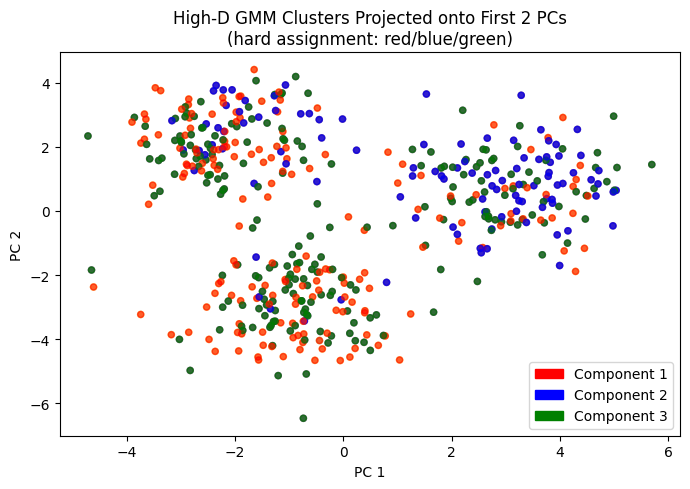

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_hd)

R_hd = e_step(X_hd, mus_hd, Sigmas_hd, pis_hd)
cluster_colors_hd = ['red', 'blue', 'green']

plt.figure(figsize=(7, 5))
for k in range(K_hd):
    alpha = R_hd[:, k]
    sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=alpha, cmap='viridis',
                     s=20, alpha=0.7, vmin=0, vmax=1)
    break  # show responsibility for component 0 as colormap

hard_labels = R_hd.argmax(axis=1)
colors_hd = np.array(['red', 'blue', 'green'])[hard_labels]
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_hd, s=20, alpha=0.6)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('High-D GMM Clusters Projected onto First 2 PCs\n(hard assignment: red/blue/green)')
patches = [mpatches.Patch(color=c, label=f'Component {i+1}') for i, c in enumerate(cluster_colors_hd)]
plt.legend(handles=patches)
plt.tight_layout()
plt.show()

### Analysis: High-Dimensional EM Behavior

**Does the algorithm converge reliably?**

With regularization ($\epsilon = 10^{-3}$), the algorithm does converge in the sense that the log-likelihood increases monotonically. However, convergence is slower and less reliable than in 2D because:
1. With only 500 samples and 50 dimensions, each component must estimate a $50 \times 50$ covariance matrix from $\sim$167 samples — this is statistically noisy.
2. The clusters overlap significantly (small mean separation), making cluster assignment ambiguous.
3. Random initialization can lead to different local optima on different runs.

**How does the condition number behave?**

The condition number of the covariance matrices tends to be high and grows with dimensions. In D=50, even with regularization:
- The covariance matrix has many small eigenvalues (directions with little variance)
- Ratio of largest to smallest eigenvalue (condition number) is large
- Without regularization, covariance matrices would be rank-deficient (singular) since we have fewer data points per cluster than dimensions
- Regularization (adding $\epsilon I$) artificially inflates small eigenvalues, keeping the condition number bounded

This demonstrates why diagonal or spherical GMM covariance assumptions (rather than full matrices) are often preferred in high-dimensional settings.